<a href="https://colab.research.google.com/github/justin3joseph/Ai-Ml_CNN-tutorials/blob/main/yolo_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
model = YOLO("yolov8n.pt")

In [9]:
from google.colab import files

uploaded = files.upload()

Saving 2.jpg to 2.jpg


In [10]:
results = model.predict(
    source=next(iter(uploaded)),
    save=True
)


image 1/1 /content/2.jpg: 576x640 5 persons, 417.3ms
Speed: 13.4ms preprocess, 417.3ms inference, 42.7ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/runs/detect/predict


(np.float64(-0.5), np.float64(1571.5), np.float64(1386.5), np.float64(-0.5))

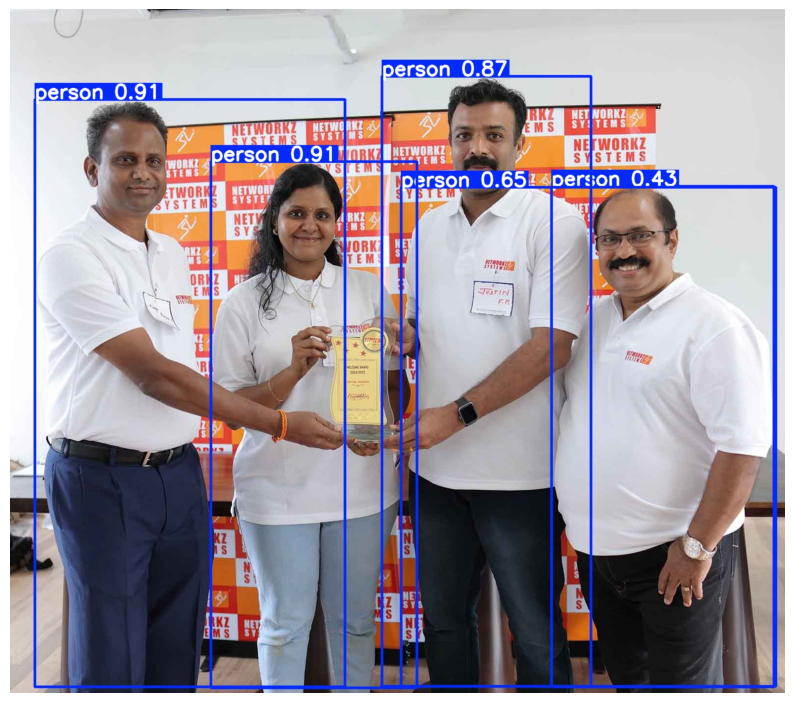

In [11]:
from PIL import Image
import matplotlib.pyplot as plt
import glob

result = glob.glob("runs/detect/predict/*.jpg")[0]

plt.figure(figsize=(10,10))
plt.imshow(Image.open(result))
plt.axis("off")

In [12]:
for result in results:

    for box in result.boxes:

        cls = int(box.cls)

        print(model.names[cls])

person
person
person
person
person


In [13]:
for result in results:

    for box in result.boxes:

        cls = int(box.cls)

        confidence = float(box.conf)

        print(model.names[cls], confidence)

person 0.9094495177268982
person 0.9053219556808472
person 0.8653648495674133
person 0.6481243968009949
person 0.425911009311676


In [14]:
for result in results:

    for box in result.boxes:

        print(box.xyxy)

tensor([[  50.6257,  183.4781,  679.5240, 1374.1049]])
tensor([[ 407.7994,  309.7449,  825.9442, 1376.1565]])
tensor([[ 754.9738,  136.7467, 1178.0122, 1373.6858]])
tensor([[ 793.2022,  361.0466, 1553.3301, 1373.2354]])
tensor([[1098.9569,  359.5245, 1549.8737, 1374.1506]])
